In [1]:
import pandas as pd
import statsmodels.formula.api as smf
import numpy as np
import matplotlib.pyplot as plt

from sklearn import metrics
from sklearn import tree
from sklearn import ensemble
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve
from sklearn.metrics import confusion_matrix, classification_report


# Titanic Dataset Description

The Titanic dataset contains information about passengers aboard the Titanic, used to predict survival outcomes. The main variables are:

- **PassengerId**: Unique identifier for each passenger.
- **Survived**: Survival (0 = No, 1 = Yes).
- **Pclass**: Ticket class (1 = 1st, 2 = 2nd, 3 = 3rd).
- **Name**: Passenger name.
- **Sex**: Gender (male/female).
- **Age**: Age in years.
- **SibSp**: Number of siblings/spouses aboard.
- **Parch**: Number of parents/children aboard.
- **Ticket**: Ticket number.
- **Fare**: Passenger fare.
- **Cabin**: Cabin number (often missing).
- **Embarked**: Port of embarkation (C = Cherbourg, Q = Queenstown, S = Southampton).

This dataset is commonly used for binary classification tasks, such as predicting whether a passenger survived based on their characteristics.

In [3]:
# Missing data is analyzed to decide which variables should be removed
df=pd.read_csv("titanic.csv")
df=df.drop("Cabin", axis=1)
df=df.dropna()

df
titanic, test = train_test_split(df, test_size=0.2, random_state=42)

In [4]:
# Rows with missing values are removed; another alternative is to perform imputation

titanic.isnull().sum()
titanic

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
472,473,1,2,"West, Mrs. Edwy Arthur (Ada Mary Worth)",female,33.0,1,2,C.A. 34651,27.7500,S
432,433,1,2,"Louch, Mrs. Charles Alexander (Alice Adelaide ...",female,42.0,1,0,SC/AH 3085,26.0000,S
666,667,0,2,"Butler, Mr. Reginald Fenton",male,25.0,0,0,234686,13.0000,S
30,31,0,1,"Uruchurtu, Don. Manuel E",male,40.0,0,0,PC 17601,27.7208,C
291,292,1,1,"Bishop, Mrs. Dickinson H (Helen Walton)",female,19.0,1,0,11967,91.0792,C
...,...,...,...,...,...,...,...,...,...,...,...
93,94,0,3,"Dean, Mr. Bertram Frank",male,26.0,1,2,C.A. 2315,20.5750,S
135,136,0,2,"Richard, Mr. Emile",male,23.0,0,0,SC/PARIS 2133,15.0458,C
338,339,1,3,"Dahl, Mr. Karl Edwart",male,45.0,0,0,7598,8.0500,S
549,550,1,2,"Davies, Master. John Morgan Jr",male,8.0,1,1,C.A. 33112,36.7500,S


In [5]:
# Logistic Regression model fit; this model predicts P(Y=1), i.e., the probability that a passenger survives according to their characteristics
modelo=smf.logit("Survived~Age+Sex+SibSp+C(Pclass)", data=titanic).fit()
print(modelo.summary())

Optimization terminated successfully.
         Current function value: 0.432623
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:               Survived   No. Observations:                  569
Model:                          Logit   Df Residuals:                      563
Method:                           MLE   Df Model:                            5
Date:                Sun, 28 Sep 2025   Pseudo R-squ.:                  0.3554
Time:                        19:23:14   Log-Likelihood:                -246.16
converged:                       True   LL-Null:                       -381.86
Covariance Type:            nonrobust   LLR p-value:                 1.398e-56
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          4.2273      0.507      8.334      0.000       3.233       5.222
Sex[T.male]      

In [6]:
# Once the logistic regression model is trained for classification (to find Y^), a cutoff theta or threshold is required
# For illustration, 0.5 is used, but this is not always the best value; it should be calculated with the ROC curve
titanic['Prob']=modelo.predict(titanic)
titanic['Y^']=np.where(titanic['Prob']>0.5,1,0)
titanic


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Prob,Y^
472,473,1,2,"West, Mrs. Edwy Arthur (Ada Mary Worth)",female,33.0,1,2,C.A. 34651,27.7500,S,0.746683,1
432,433,1,2,"Louch, Mrs. Charles Alexander (Alice Adelaide ...",female,42.0,1,0,SC/AH 3085,26.0000,S,0.674204,1
666,667,0,2,"Butler, Mr. Reginald Fenton",male,25.0,0,0,234686,13.0000,S,0.273887,0
30,31,0,1,"Uruchurtu, Don. Manuel E",male,40.0,0,0,PC 17601,27.7208,C,0.478163,0
291,292,1,1,"Bishop, Mrs. Dickinson H (Helen Walton)",female,19.0,1,0,11967,91.0792,C,0.957239,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
93,94,0,3,"Dean, Mr. Bertram Frank",male,26.0,1,2,C.A. 2315,20.5750,S,0.064462,0
135,136,0,2,"Richard, Mr. Emile",male,23.0,0,0,SC/PARIS 2133,15.0458,C,0.289794,0
338,339,1,3,"Dahl, Mr. Karl Edwart",male,45.0,0,0,7598,8.0500,S,0.045230,0
549,550,1,2,"Davies, Master. John Morgan Jr",male,8.0,1,1,C.A. 33112,36.7500,S,0.336497,0


In [7]:
# Confusion matrix, contrasts predictions with actual Y values; used to obtain classification performance metrics
pd.crosstab( titanic['Survived'], titanic['Y^'])

Y^,0,1
Survived,,
0,295,49
1,59,166


In [8]:
#Accuracy
(295+166)/(295+59+49+166)

0.8101933216168717

In [9]:
print(classification_report(titanic['Survived'], titanic['Y^']))

              precision    recall  f1-score   support

           0       0.83      0.86      0.85       344
           1       0.77      0.74      0.75       225

    accuracy                           0.81       569
   macro avg       0.80      0.80      0.80       569
weighted avg       0.81      0.81      0.81       569



In [10]:
#If you want to determine the best cutoff theta for classification, you need the ROC curve
# This curve has 1-specificity or fpr (false positive rate) on the X axis, while Y
# has sensitivity or tpr (true positive rate). The following code obtains tpr, fpr, and the thresholds found with them

fpr, tpr, thresholds = roc_curve(titanic['Survived'], titanic['Prob'])
print('False Positive Rate:', fpr)
print('True Positive Rate:', tpr)
print('Thresholds:', thresholds)

False Positive Rate: [0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.00290698 0.00290698 0.00290698 0.00290698 0.00290698
 0.00290698 0.00290698 0.00290698 0.00581395 0.00581395 0.00581395
 0.00872093 0.00872093 0.00872093 0.00872093 0.00872093 0.00872093
 0.00872093 0.00872093 0.00872093 0.00872093 0.01162791 0.01162791
 0.01453488 0.01453488 0.01744186 0.01744186 0.02034884 0.02034884
 0.02034884 0.02034884 0.02325581 0.02325581 0.02325581 0.02616279
 0.02616279 0.02906977 0.02906977 0.0377907  0.0377907  0.0377907
 0.0377907  0.04069767 0.04360465 0.04651163 0.04651163 0.0494186
 0.0494186  0.05232558 0.05813953 0.05813953 0.06104651 0.06395349
 0.06686047 0.06686047 0.06976744 0.06976744 0.06976744 0.07267442
 0.07267442 0.0755814  0.0872093  0.0872093  0.09011628 0.09593023
 0.09883721 0.11046512 0.11337209 0.11627907 0.11627907 0.11918605
 0.11918605 0.11918605 0.12209302 0.125      0.12790698 0.1

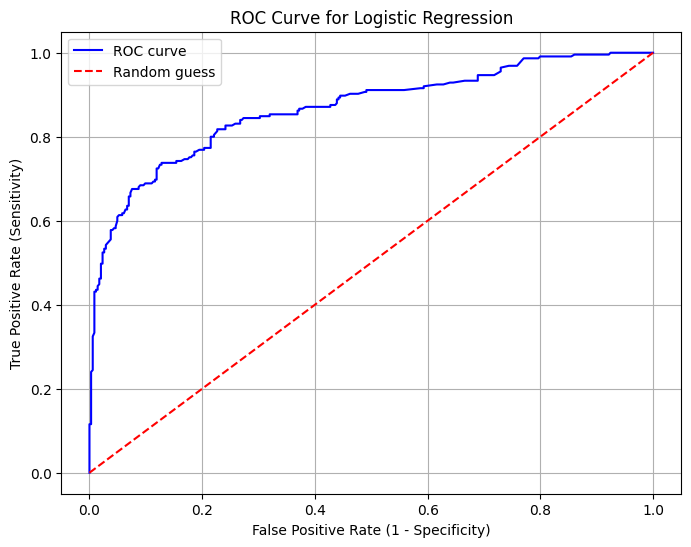

In [11]:
#ROC curve plot
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='blue', label='ROC curve')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random guess')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curve for Logistic Regression')
plt.legend()
plt.grid(True)
plt.show()

In [12]:
# Measure the area under the curve (AUC)
auc = metrics.roc_auc_score(titanic['Survived'], titanic['Prob'])
print('Area Under the Curve (AUC):', auc)

Area Under the Curve (AUC): 0.8671188630490956


In [13]:
# With the information from fpr, tpr, and thresholds, you can estimate a metric known as Youden
# With this metric, youden = sensitivity + specificity - 1; we want to maximize this value

youden_index = tpr - fpr
max_youden = np.argmax(youden_index)
best_threshold = thresholds[max_youden]
print('Best threshold (max Youden):', best_threshold)
print('Youden index at best threshold:', youden_index[max_youden])

Best threshold (max Youden): 0.5128540053708205
Youden index at best threshold: 0.6098708010335917


In [14]:
# Use best threshold to predict, create confusion matrix and get classification report

titanic['Y_pred_best'] = np.where(titanic['Prob'] > best_threshold, 1, 0)
cm = confusion_matrix(titanic['Survived'], titanic['Y_pred_best'])
print('Confusion Matrix:')
print(cm)

print('Classification Report:')
print(classification_report(titanic['Survived'], titanic['Y_pred_best']))

Confusion Matrix:
[[300  44]
 [ 60 165]]
Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.87      0.85       344
           1       0.79      0.73      0.76       225

    accuracy                           0.82       569
   macro avg       0.81      0.80      0.81       569
weighted avg       0.82      0.82      0.82       569



In [15]:
# classification report for test data
test['Prob_test']=modelo.predict(test)
test['Y_pred_test'] = np.where(test['Prob_test'] > best_threshold, 1, 0)
cm_test = confusion_matrix(test['Survived'], test['Y_pred_test'])
print('Confusion Matrix for Test Data:')
print(cm_test)
print('Classification Report for Test Data:')
print(classification_report(test['Survived'], test['Y_pred_test']))

Confusion Matrix for Test Data:
[[73  7]
 [21 42]]
Classification Report for Test Data:
              precision    recall  f1-score   support

           0       0.78      0.91      0.84        80
           1       0.86      0.67      0.75        63

    accuracy                           0.80       143
   macro avg       0.82      0.79      0.79       143
weighted avg       0.81      0.80      0.80       143



In [ ]:
# A key metric for evaluating a classification model is the AUC or area under the curve; the maximum value is 1
# We want values greater than 0.8


Solve the titanic problem with a end to end ML structure. Use sklearn to compare 3 classification algorithms. Create pipelines to compare the models, and create a pipeline for the new model to make predictions of the new data. Analyze your results.

In [16]:
import pandas as pd
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

In [19]:
# Loading the data
df_train = pd.read_csv("titanic.csv")
X = df_train.drop("Survived", axis=1)
y = df_train["Survived"]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Correctly categorize Pclass
numerical_features = ['Age', 'Fare', 'SibSp', 'Parch']
categorical_features = ['Pclass', 'Sex', 'Embarked']

# Create preprocessing pipelines for numerical and categorical data.
# Imputers will handle null data
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Use ColumnTransformer to apply different transformations to different columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='drop' # Drop other columns like Name, Ticket, Cabin, PassengerId
)


In [20]:
# 3 models defined
models = {
    "Logistic Regression": LogisticRegression(solver='liblinear', random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42)
}

# Creating pipelines for each model
pipelines = {name: Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)])
             for name, model in models.items()}

# Evaluate models using cross-validation
results = {}
for name, pipeline in pipelines.items():
    print(f"Evaluating {name}...")
    cv_results = cross_validate(pipeline, X_train, y_train, cv=5,
                                scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'],
                                return_train_score=True)
    results[name] = cv_results

# Set to analyze cross-validation results
for name, cv_results in results.items():
    print(f"\n--- {name} ---")
    for metric in ['test_accuracy', 'test_roc_auc', 'test_f1']:
        mean_score = np.mean(cv_results[metric])
        std_score = np.std(cv_results[metric])
        print(f"Mean {metric.split('_')[-1].upper()}: {mean_score:.4f} (+/- {std_score:.4f})")


Evaluating Logistic Regression...
Evaluating Random Forest...
Evaluating Gradient Boosting...

--- Logistic Regression ---
Mean ACCURACY: 0.7935 (+/- 0.0253)
Mean AUC: 0.8396 (+/- 0.0256)
Mean F1: 0.7051 (+/- 0.0462)

--- Random Forest ---
Mean ACCURACY: 0.7880 (+/- 0.0315)
Mean AUC: 0.8394 (+/- 0.0162)
Mean F1: 0.7132 (+/- 0.0345)

--- Gradient Boosting ---
Mean ACCURACY: 0.8146 (+/- 0.0169)
Mean AUC: 0.8500 (+/- 0.0130)
Mean F1: 0.7320 (+/- 0.0302)



Training Logistic Regression on the full training set...

Training Random Forest on the full training set...

Training Gradient Boosting on the full training set...

--- Evaluating Models on the Test Set ---

--- Logistic Regression ---
Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.86      0.83       105
           1       0.78      0.72      0.75        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179


--- Random Forest ---
Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.88      0.86       105
           1       0.81      0.76      0.78        74

    accuracy                           0.83       179
   macro avg       0.82      0.82      0.82       179
weighted avg       0.83      0.83      0.83       179


--- Gradient Boosting ---
Classificati

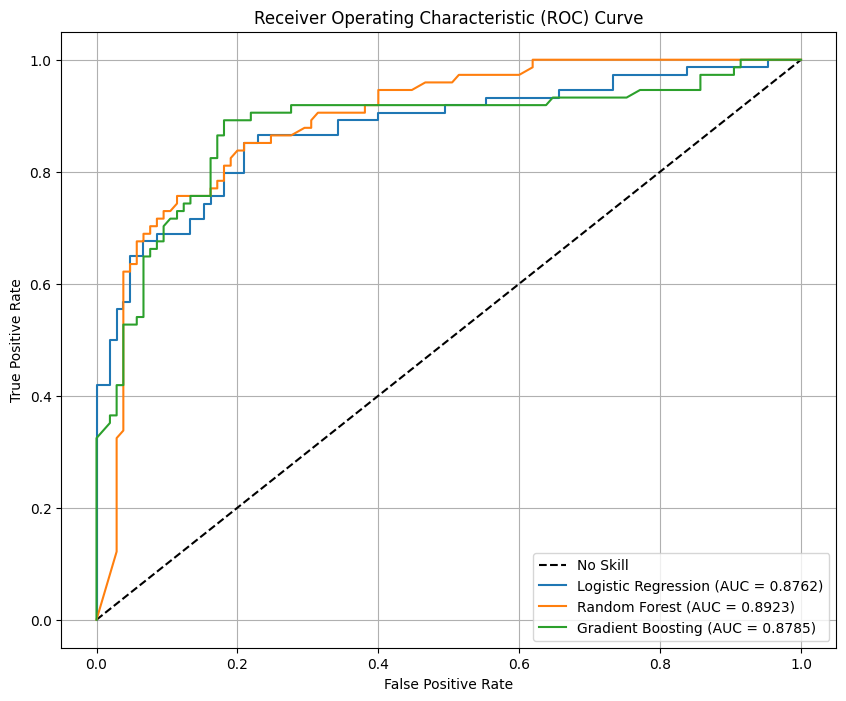

In [23]:
# Train each pipeline on the full training data
trained_pipelines = {}
for name, pipeline in pipelines.items():
    print(f"\nTraining {name} on the full training set...")
    pipeline.fit(X_train, y_train)
    trained_pipelines[name] = pipeline

# Evaluate each model on the hold-out test set
print("\n--- Evaluating Models on the Test Set ---")
plt.figure(figsize=(10, 8))
plt.plot([0, 1], [0, 1], 'k--', label='No Skill')

for name, pipeline in trained_pipelines.items():
    # Make predictions and get probabilities for the positive class
    y_pred = pipeline.predict(X_test)
    y_pred_proba = pipeline.predict_proba(X_test)[:, 1]

    # Print the classification report
    print(f"\n--- {name} ---")
    print("Classification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    # Calculate ROC curve and AUC
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)

    # Plot the ROC curve
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})')

# Finalize the ROC plot
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


Analysis of model performance:
1. The Random Forest model has the highest overall accuracy (83%) and the best balance of precision and recall for both classes.This model is the most balanced and accurate overall. It's the best at correctly predicting both who survived and who didn't.

2. The Gradient Boosting model is slightly better at identifying people who did not survive (90% recall), but it makes more mistakes on the survivor class. It is not as good at identifying survivors (Class 1), with a lower recall of 72%.

3. The Logistic Regression model is a solid baseline, with decent performance (80% accuracy) despite being a simpler model. It has the lowest accuracy and overall performance compared to the other two models.


In [28]:
# Based on analysis (the highest ROC AUC and Accuracy), selected Random Forest model
best_model_name = "Random Forest"
best_pipeline = pipelines[best_model_name]


print(f"Training the final '{best_model_name}' model on the training subset...")
best_pipeline.fit(X_train, y_train)

# Make predictions using the best pipeline on the INTERNAL hold-out test set (X_test)
print("\nMaking predictions on the internal X_test data...")
predictions = best_pipeline.predict(X_test)



Training the final 'Random Forest' model on the training subset...

Making predictions on the internal X_test data...


In [33]:
# To demonstrate the model's performance on the unseen data,generated a final classification report and print the accuracy score.
print("\n--- Final Evaluation of Best Model on X_test ---")
print(f"Accuracy on X_test: {best_pipeline.score(X_test, y_test):.4f}")
print("\nClassification Report on X_test:")
print(classification_report(y_test, predictions, zero_division=0))


--- Final Evaluation of Best Model on X_test ---
Accuracy on X_test: 0.8268

Classification Report on X_test:
              precision    recall  f1-score   support

           0       0.84      0.88      0.86       105
           1       0.81      0.76      0.78        74

    accuracy                           0.83       179
   macro avg       0.82      0.82      0.82       179
weighted avg       0.83      0.83      0.83       179



The final evaluation shows the Random Forest model performs well on the unseen test data. The results are balanced performance across both classes.
The model correctly predicts the outcome for about 83% of the test cases. This proved the model generalizes well to new data.

Performance by class
For Class 0 (did not survive):

1.When the model predicts that someone did not survive, it is correct 84%(percision) of the time. This means there are relatively few "false alarms" for this class.

2. The model correctly identifies 88%(recall) of all the people who actually did not survive. This is very good, showing the model is effective at catching the majority of this group.

For Class 1 (survived):

1. When the model predicts that someone survived, it is correct 81%(perision) of the time, another example of a good result

2. The model successfully identifies 76% of all the people who actually survived. This is a bit lower than the recall for Class 0. This might suggest the model is slightly less effective at finding survivors compared to non-survivors.

Summary of model:

Strengths: The model performs consistently well for both classes and has a high overall accuracy. It is particularly strong at identifying non-survivors (Class 0).

Potential improvement: The model's ability to recall survivors (Class 1) is a bit lower. Further tuning could focus on improving recall for this class.

In [38]:
#testing thresholds to see if I can get recall survivors (Class 1)

import numpy as np
from sklearn.metrics import classification_report

# 1. Getting predictions using the default threshold (0.5) via .predict()
y_pred_default = best_pipeline.predict(X_test)

# 2. Get the raw probability scores
y_pred_proba = best_pipeline.predict_proba(X_test)

# 3. Apply a manual 0.5 threshold to the probabilities
y_pred_manual_05 = (y_pred_proba[:, 1] > 0.5).astype(int)

# 4. Compare the two sets of predictions
# They should be identical
assert np.array_equal(y_pred_default, y_pred_manual_05)
print("The default .predict() threshold is confirmed to be 0.5.")

# adjusted (0.5) Threshold
print("\n--- Default (0.5) Threshold Classification Report ---")
print(classification_report(y_test, y_pred_default, zero_division=0))

#  adjusted (0.51) threshold
new_threshold = 0.4
y_pred_adjusted = (y_pred_proba[:, 1] > new_threshold).astype(int)
print("\n--- Adjusted (0.51) Threshold Classification Report ---")
print(classification_report(y_test, y_pred_adjusted, zero_division=0))

# adjusted (0.4) threshold
new_threshold = 0.4
y_pred_adjusted = (y_pred_proba[:, 1] > new_threshold).astype(int)
print("\n--- Adjusted (0.4) Threshold Classification Report ---")
print(classification_report(y_test, y_pred_adjusted, zero_division=0))



The default .predict() threshold is confirmed to be 0.5.

--- Default (0.5) Threshold Classification Report ---
              precision    recall  f1-score   support

           0       0.84      0.88      0.86       105
           1       0.81      0.76      0.78        74

    accuracy                           0.83       179
   macro avg       0.82      0.82      0.82       179
weighted avg       0.83      0.83      0.83       179


--- Adjusted (0.51) Threshold Classification Report ---
              precision    recall  f1-score   support

           0       0.88      0.80      0.84       105
           1       0.75      0.84      0.79        74

    accuracy                           0.82       179
   macro avg       0.81      0.82      0.81       179
weighted avg       0.82      0.82      0.82       179


--- Adjusted (0.4) Threshold Classification Report ---
              precision    recall  f1-score   support

           0       0.88      0.80      0.84       105
           1

Conclusion, these three reports perfectly illustrates the precision-recall trade-off. The threshold of 0.5 still offer the most balance. When increased slightly to .51, we get a high confidence of list of survivors. When it is decreased it is better at identfying more potential suriviors. But To increase precision, makes it a lower recall ( we miss more of the actual survivors.)